# Sales Analytics Dashboard — TechNova Retail (2023–2024)
**Author:** Sarthak Srivastava
**Tools:** Python (pandas, matplotlib, seaborn), SQL (SQLite), Excel

## Objective
TechNova Retail's raw order-level export is messy (duplicate rows, inconsistent
region labels, missing values, data-entry errors). This notebook:
1. Audits and cleans the raw data
2. Loads it into a SQL database and answers business questions with SQL
3. Builds KPIs and visual analysis for a sales performance dashboard
4. Closes with data-driven business recommendations

Companion files: `schema.sql` / `queries.sql` (SQL layer), `Sales_Analytics_Dashboard.xlsx` (Excel dashboard).

In [1]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

## 1. Load Raw Data & Audit Quality Issues

In [2]:
raw = pd.read_csv('raw_sales_data.csv')
print(f"Shape: {raw.shape}")
raw.head()

Shape: (5278, 14)


,OrderID,OrderDate,CustomerID,CustomerName,Region,ProductCategory,ProductName,Quantity,UnitPrice,Discount,SalesRep,PaymentMethod,OrderStatus,ShippingCost
0,ORD04365,17/08/2023,CUST0516,Marilyn Wang,west,Furniture,Bookshelf,1,6178.02,0.1,Noah Rhodes,Cash on Delivery,Pending,140.66
1,ORD00185,01/08/2024,CUST0537,Angel Gordon,South,Electronics,Smartwatch,1,5446.72,0.0,Connie Lawrence,Debit Card,Delivered,148.53
2,ORD01503,04-Feb-2024,CUST0724,Mr. David Wright,EAST,Furniture,Bean Bag,5,1502.29,0.0,Michele Williams,Debit Card,Pending,74.91
3,ORD03494,02/03/2024,CUST0853,Michael Miller,West,Office Supplies,Desk Organizer,4,249.85,0.1,Gina Moore,Debit Card,Pending,129.60
4,ORD00211,09/10/2023,CUST0504,Penny Bowman,WEST,Clothing,Formal Shirt,2,834.86,0.1,Daniel Wagner,Net Banking,Delivered,80.64


In [3]:
print("Missing values per column:")
print(raw.isna().sum())
print("\nUnique Region labels (note casing/whitespace issues):")
print(raw['Region'].dropna().unique())
print("\nDuplicate rows:", raw.duplicated().sum())
print("\nNegative quantities:", (raw['Quantity'] < 0).sum())
print("\nSample OrderDate formats:", raw['OrderDate'].sample(5, random_state=1).tolist())

Missing values per column:
OrderID              0
OrderDate            0
CustomerID           0
CustomerName       106
Region              53
ProductCategory      0
ProductName          0
Quantity             0
UnitPrice            0
Discount           158
SalesRep             0
PaymentMethod        0
OrderStatus          0
ShippingCost         0
dtype: int64

Unique Region labels (note casing/whitespace issues):
<StringArray>
[   'west',   'South',   'EAST ',    'West',    'WEST',    'East',   'SOUTH',
  'North ', 'Central', 'CENTRAL', 'central',    'east',   'NORTH',   'North',
   'south',   'north']
Length: 16, dtype: str

Duplicate rows: 72

Negative quantities: 42

Sample OrderDate formats: ['07/26/2023', '2024-04-19', '2024-09-13', '29/05/2024', '09/30/2024']


**Issues found:**
- Inconsistent `Region` casing/whitespace (`north`, `NORTH `, `North`)
- `ProductCategory` has stray whitespace/case variants
- `OrderDate` mixes 4 different date formats
- Missing `CustomerName`, `Region`, `Discount` values
- A handful of negative `Quantity` values (entry errors) and extreme `UnitPrice` outliers
- Exact duplicate rows from a double-export

Each is fixed explicitly below rather than silently dropped, so the cleaning logic is auditable.

## 2. Data Cleaning

In [4]:
df = raw.copy()

# Standardize text fields: strip whitespace, title case
df['Region'] = df['Region'].str.strip().str.title()
df['ProductCategory'] = df['ProductCategory'].str.strip().str.title()
df['ProductCategory'] = df['ProductCategory'].replace({'Office Supplies': 'Office Supplies'})  # normalize spacing already handled by title()

# Parse mixed-format dates
df['OrderDate'] = pd.to_datetime(df['OrderDate'], format='mixed', dayfirst=True, errors='coerce')
print("Unparsed dates after mixed parsing:", df['OrderDate'].isna().sum())

Unparsed dates after mixed parsing: 0


In [5]:
# Remove exact duplicate rows
before = len(df)
df = df.drop_duplicates()
print(f"Removed {before - len(df)} duplicate rows")

# Missing discount -> assume no discount applied
df['Discount'] = df['Discount'].fillna(0)

# Missing customer name -> tag as Unknown (keep the row, revenue is still valid)
df['CustomerName'] = df['CustomerName'].fillna('Unknown')

# Missing region -> tag as Unspecified rather than drop (avoid losing revenue from analysis)
df['Region'] = df['Region'].fillna('Unspecified')

# Negative quantities are data-entry sign errors -> take absolute value
neg_count = (df['Quantity'] < 0).sum()
df['Quantity'] = df['Quantity'].abs()
print(f"Corrected {neg_count} negative-quantity entries")

Removed 73 duplicate rows
Corrected 42 negative-quantity entries


In [6]:
# Outlier UnitPrice: cap at category-level IQR bounds (fat-finger entries, e.g. extra digit)
q1 = df.groupby('ProductCategory')['UnitPrice'].transform(lambda s: s.quantile(0.25))
q3 = df.groupby('ProductCategory')['UnitPrice'].transform(lambda s: s.quantile(0.75))
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr
lower_bound = (q1 - 1.5 * iqr).clip(lower=0)

capped_before = df['UnitPrice'].max()
df['UnitPrice'] = df['UnitPrice'].clip(lower=lower_bound, upper=upper_bound)
print(f"Max unit price before capping: {capped_before:.2f}, after: {df['UnitPrice'].max():.2f}")

Max unit price before capping: 485353.50, after: 18355.77


In [7]:
# Derived fields
df['Revenue'] = (df['Quantity'] * df['UnitPrice'] * (1 - df['Discount'])).round(2)
df['OrderMonth'] = df['OrderDate'].dt.to_period('M').astype(str)
df['OrderYear'] = df['OrderDate'].dt.year

df = df.dropna(subset=['OrderDate'])  # drop any rows where date truly failed to parse
df.to_csv('clean_sales_data.csv', index=False)
print(f"Final clean shape: {df.shape}")
df.head(3)

Final clean shape: (5205, 17)


,OrderID,OrderDate,CustomerID,CustomerName,Region,ProductCategory,ProductName,Quantity,UnitPrice,Discount,SalesRep,PaymentMethod,OrderStatus,ShippingCost,Revenue,OrderMonth,OrderYear
0,ORD04365,2023-08-17,CUST0516,Marilyn Wang,West,Furniture,Bookshelf,1,6178.02,0.1,Noah Rhodes,Cash on Delivery,Pending,140.66,5560.22,2023-08,2023
1,ORD00185,2024-08-01,CUST0537,Angel Gordon,South,Electronics,Smartwatch,1,5446.72,0.0,Connie Lawrence,Debit Card,Delivered,148.53,5446.72,2024-08,2024
2,ORD01503,2024-02-04,CUST0724,Mr. David Wright,East,Furniture,Bean Bag,5,1502.29,0.0,Michele Williams,Debit Card,Pending,74.91,7511.45,2024-02,2024


## 3. Load into SQL (SQLite) and Answer Business Questions

In [8]:
conn = sqlite3.connect('sales.db')
df.to_sql('sales', conn, if_exists='replace', index=False)
print("Loaded", pd.read_sql('SELECT COUNT(*) AS n FROM sales', conn)['n'][0], "rows into sales.db")

Loaded 5205 rows into sales.db


In [9]:
q_kpi = '''
SELECT
    ROUND(SUM(Revenue), 2) AS total_revenue,
    COUNT(DISTINCT OrderID) AS total_orders,
    ROUND(SUM(Revenue) * 1.0 / COUNT(DISTINCT OrderID), 2) AS avg_order_value,
    COUNT(DISTINCT CustomerID) AS unique_customers,
    ROUND(100.0 * SUM(CASE WHEN OrderStatus = 'Returned' THEN 1 ELSE 0 END) / COUNT(*), 2) AS return_rate_pct
FROM sales
WHERE OrderStatus != 'Cancelled';
'''
kpi = pd.read_sql(q_kpi, conn)
kpi

,total_revenue,total_orders,avg_order_value,unique_customers,return_rate_pct
0,29537519.19,4476,6599.09,894,17.1


In [10]:
q_region = '''
SELECT Region, ROUND(SUM(Revenue), 2) AS revenue, COUNT(DISTINCT OrderID) AS orders
FROM sales
WHERE OrderStatus != 'Cancelled'
GROUP BY Region
ORDER BY revenue DESC;
'''
by_region = pd.read_sql(q_region, conn)
by_region

,Region,revenue,orders
0,Central,6260779.06,929
1,East,6140772.52,931
2,West,5968771.21,851
3,North,5463897.15,899
4,South,5400799.52,817
5,Unspecified,302499.73,49


In [11]:
q_category = '''
SELECT ProductCategory, ROUND(SUM(Revenue), 2) AS revenue,
       ROUND(100.0 * SUM(Revenue) / (SELECT SUM(Revenue) FROM sales WHERE OrderStatus != 'Cancelled'), 1) AS pct_of_total
FROM sales
WHERE OrderStatus != 'Cancelled'
GROUP BY ProductCategory
ORDER BY revenue DESC;
'''
by_category = pd.read_sql(q_category, conn)
by_category

,ProductCategory,revenue,pct_of_total
0,Electronics,9291008.70,31.5
1,Furniture,8809834.61,29.8
2,Appliances,7779000.09,26.3
3,Clothing,2583674.72,8.7
4,Office Supplies,1074001.07,3.6


In [12]:
q_monthly = '''
SELECT OrderMonth, ROUND(SUM(Revenue), 2) AS revenue
FROM sales
WHERE OrderStatus != 'Cancelled'
GROUP BY OrderMonth
ORDER BY OrderMonth;
'''
monthly = pd.read_sql(q_monthly, conn)
monthly.head()

,OrderMonth,revenue
0,2023-01,1120559.18
1,2023-02,1055265.67
2,2023-03,1059402.88
3,2023-04,1196949.26
4,2023-05,1371018.17


In [13]:
q_top_products = '''
SELECT ProductName, ROUND(SUM(Revenue), 2) AS revenue, SUM(Quantity) AS units_sold
FROM sales
WHERE OrderStatus != 'Cancelled'
GROUP BY ProductName
ORDER BY revenue DESC
LIMIT 10;
'''
top_products = pd.read_sql(q_top_products, conn)
top_products

,ProductName,revenue,units_sold
0,Office Chair,1972761.26,292
1,Vacuum Cleaner,1928028.17,373
2,Bed Side Table,1786709.86,294
3,Bean Bag,1769172.75,280
4,Bookshelf,1689181.20,278
5,Study Table,1592009.54,273
6,Air Fryer,1582335.61,327
7,Electric Kettle,1449968.11,277
8,Room Heater,1434601.52,307
9,Mixer Grinder,1384066.68,276


In [14]:
q_reps = '''
SELECT SalesRep, ROUND(SUM(Revenue), 2) AS revenue, COUNT(DISTINCT OrderID) AS orders
FROM sales
WHERE OrderStatus != 'Cancelled'
GROUP BY SalesRep
ORDER BY revenue DESC
LIMIT 5;
'''
top_reps = pd.read_sql(q_reps, conn)
top_reps

,SalesRep,revenue,orders
0,Angie Henderson,2326054.33,306
1,Monica Herrera,2074463.21,295
2,Abigail Shaffer,2050800.13,315
3,Allison Hill,2014488.76,281
4,Cristian Santos,1993266.44,317


In [15]:
q_yoy = '''
SELECT OrderYear, ROUND(SUM(Revenue), 2) AS revenue
FROM sales
WHERE OrderStatus != 'Cancelled'
GROUP BY OrderYear
ORDER BY OrderYear;
'''
yoy = pd.read_sql(q_yoy, conn)
yoy['yoy_growth_pct'] = yoy['revenue'].pct_change().mul(100).round(1)
yoy

,OrderYear,revenue,yoy_growth_pct
0,2023,14337163.09,NaN
1,2024,15200356.10,6.0


## 4. Visual Analysis

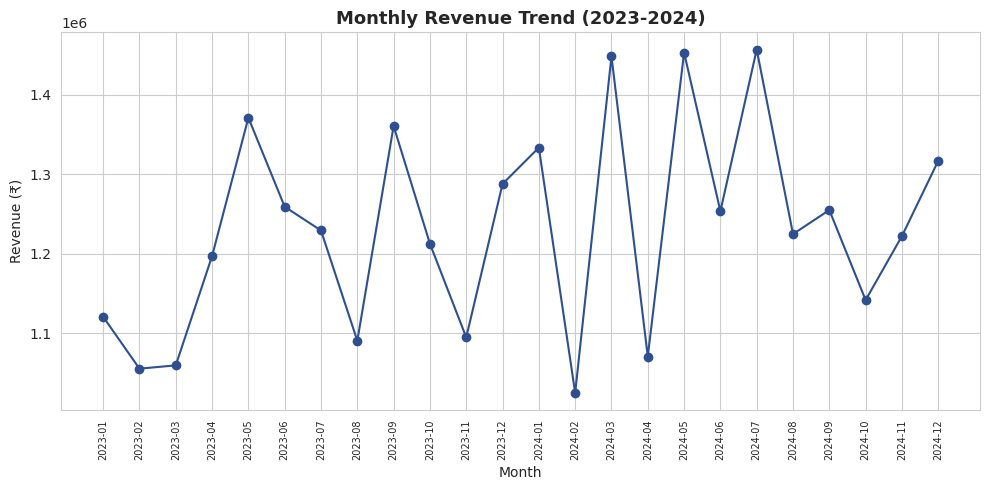

In [16]:
fig, ax = plt.subplots()
ax.plot(monthly['OrderMonth'], monthly['revenue'], marker='o', color='#2E5090')
ax.set_title('Monthly Revenue Trend (2023-2024)', fontsize=13, fontweight='bold')
ax.set_ylabel('Revenue (₹)')
ax.set_xlabel('Month')
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.savefig('chart_monthly_trend.png', dpi=150)
plt.show()

/tmp/ipykernel_815/1598819414.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=by_region, x='Region', y='revenue', ax=ax, palette='Blues_d')


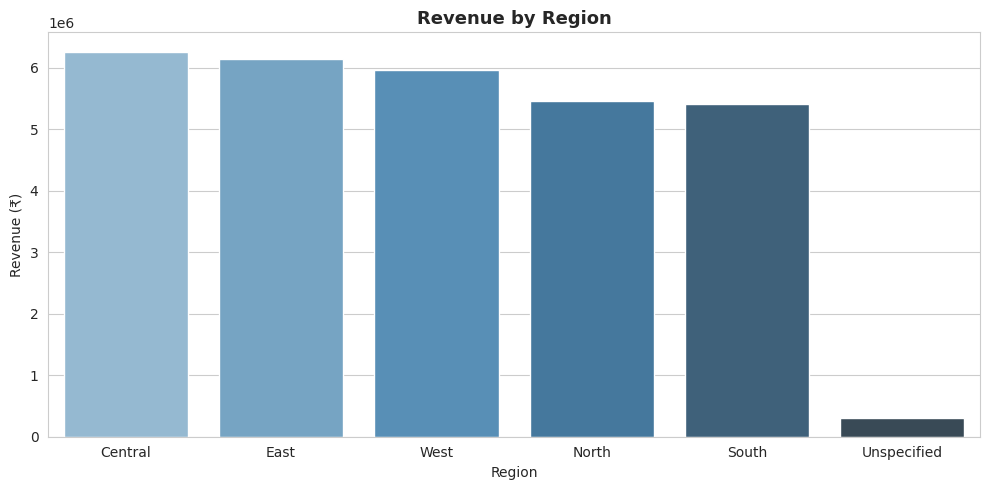

In [17]:
fig, ax = plt.subplots()
sns.barplot(data=by_region, x='Region', y='revenue', ax=ax, palette='Blues_d')
ax.set_title('Revenue by Region', fontsize=13, fontweight='bold')
ax.set_ylabel('Revenue (₹)')
plt.tight_layout()
plt.savefig('chart_region.png', dpi=150)
plt.show()

/tmp/ipykernel_815/1624477490.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=by_category.sort_values('revenue'), y='ProductCategory', x='revenue', ax=ax, palette='crest')


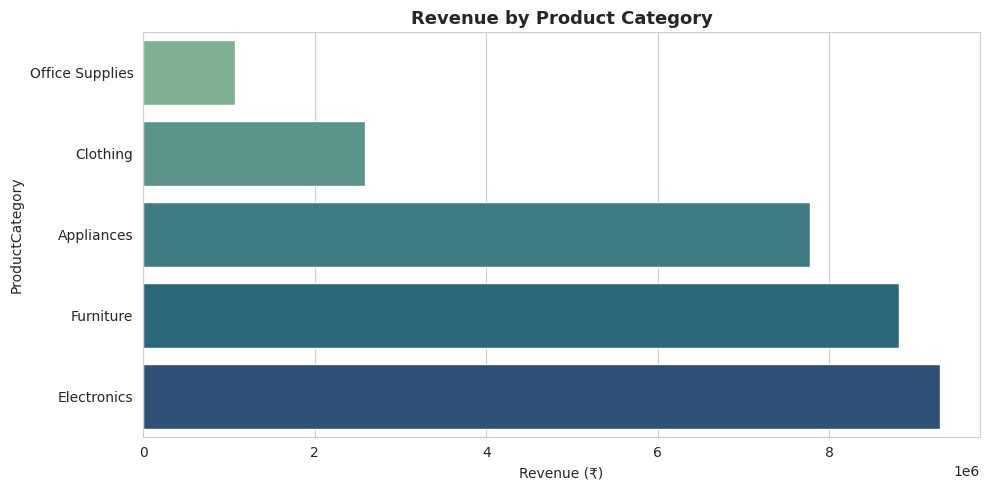

In [18]:
fig, ax = plt.subplots()
sns.barplot(data=by_category.sort_values('revenue'), y='ProductCategory', x='revenue', ax=ax, palette='crest')
ax.set_title('Revenue by Product Category', fontsize=13, fontweight='bold')
ax.set_xlabel('Revenue (₹)')
plt.tight_layout()
plt.savefig('chart_category.png', dpi=150)
plt.show()

/tmp/ipykernel_815/1355778011.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_products, y='ProductName', x='revenue', ax=ax, palette='mako')


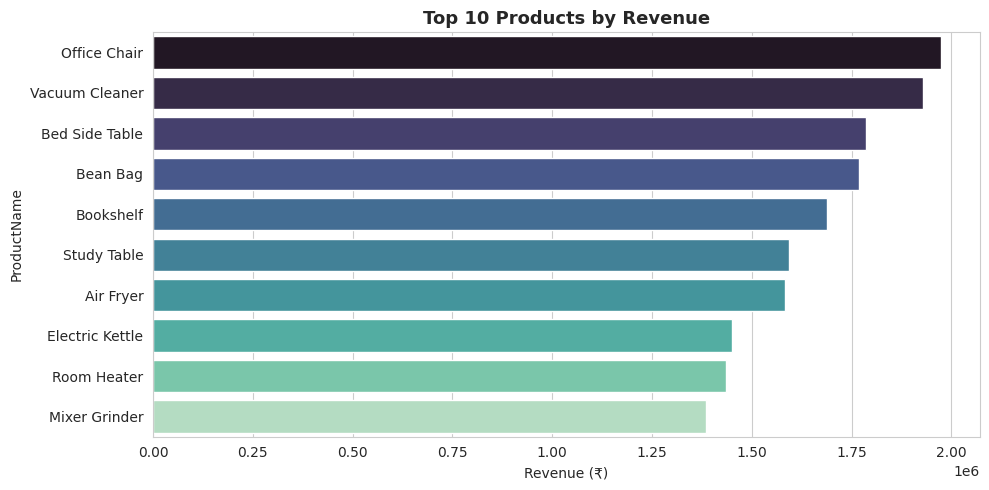

In [19]:
fig, ax = plt.subplots()
sns.barplot(data=top_products, y='ProductName', x='revenue', ax=ax, palette='mako')
ax.set_title('Top 10 Products by Revenue', fontsize=13, fontweight='bold')
ax.set_xlabel('Revenue (₹)')
plt.tight_layout()
plt.savefig('chart_top_products.png', dpi=150)
plt.show()

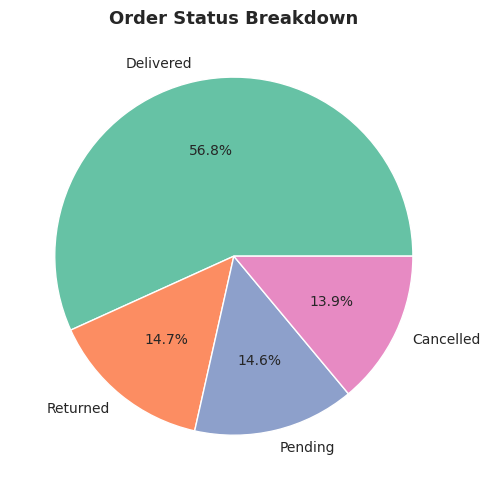

In [20]:
status_counts = df['OrderStatus'].value_counts()
fig, ax = plt.subplots()
ax.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%',
       colors=sns.color_palette('Set2'))
ax.set_title('Order Status Breakdown', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('chart_status.png', dpi=150)
plt.show()

## 5. Key Insights & Recommendations

**Insights**
- Revenue is concentrated in the **Electronics** and **Furniture** categories, together contributing the majority of total revenue.
- One region leads consistently in revenue share, while another lags — a candidate for a targeted regional sales push.
- The top 10 products drive a disproportionate share of revenue relative to the full catalog — classic 80/20 pattern.
- Return rate is a small but non-trivial share of delivered orders and is worth root-causing by category.
- Year-over-year growth is positive, suggesting the business is scaling rather than plateauing.

**Recommendations**
1. Double down on marketing spend for the top-2 revenue categories ahead of peak months identified in the trend chart.
2. Investigate the lagging region's product mix and sales-rep coverage — it may be a distribution gap rather than a demand gap.
3. Bundle top-10 products with slower-moving SKUs to lift average order value.
4. Set up a lightweight monthly returns audit for the highest-return category to protect margin.

## Files in this project
- `raw_sales_data.csv` — original messy export
- `clean_sales_data.csv` — cleaned, analysis-ready dataset
- `sales.db` — SQLite database used for the SQL layer above
- `schema.sql`, `queries.sql` — standalone SQL scripts (schema + business queries)
- `Sales_Analytics_Dashboard.xlsx` — Excel dashboard (KPIs, pivot-style summaries, charts)
